# Corrigé — Simulation d'examen bayésien

## Version alignée avec les TP

Cette correction utilise une syntaxe volontairement simple, proche des notebooks de TP :

- `np.random.binomial`
- `pm.Model()`
- `pm.Bernoulli`
- `pm.Binomial`
- `pm.Beta`
- `pm.Categorical`
- `pm.math.switch`
- `az.summary`
- `az.plot_posterior`
- `az.plot_dist`
- `az.compare`
- `pm.sample_posterior_predictive`


## Imports

In [1]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

np.random.seed(42)
az.style.use("arviz-whitegrid")

---
# Exercice 1 — Smart Sensor Reliability


In [2]:
p_anomaly = 0.12
n = 150

sensor_data = np.random.binomial(1, p_anomaly, size=n)

freq_obs = sensor_data.mean()

print("Nombre d'anomalies observées :", sensor_data.sum())
print("Fréquence empirique observée :", freq_obs)

Nombre d'anomalies observées : 18
Fréquence empirique observée : 0.12


## Simulation Monte Carlo

On répète 2500 fois une expérience de taille 150.
Chaque ligne de `sim` représente une expérience complète.

In [3]:
N = 2500

sim = np.random.binomial(1, p_anomaly, size=(N, n))
freqs = sim.mean(axis=1)

print("Moyenne des fréquences simulées :", freqs.mean())
print("Écart-type des fréquences simulées :", freqs.std())

Moyenne des fréquences simulées : 0.11992
Écart-type des fréquences simulées : 0.027140339799723297


<Axes: >

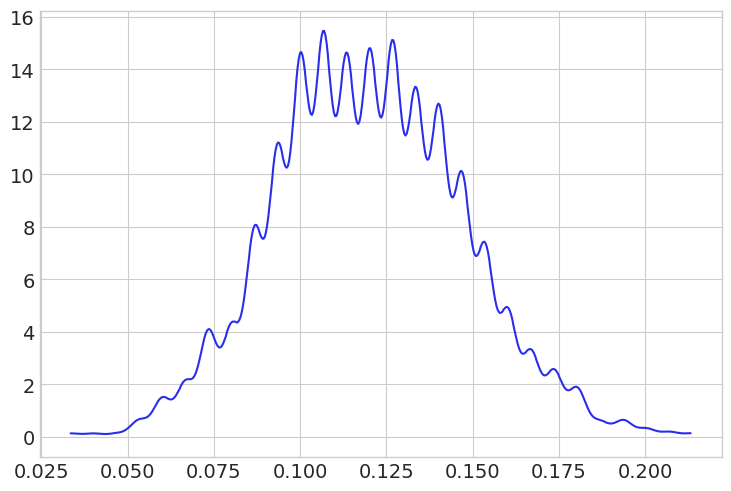

In [4]:
az.plot_dist(freqs)


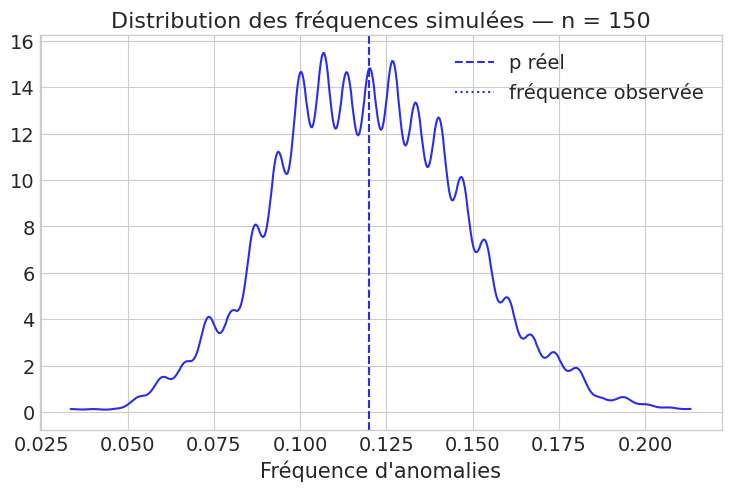

In [5]:
az.plot_dist(freqs)
plt.axvline(p_anomaly, linestyle="--", label="p réel")
plt.axvline(freq_obs, linestyle=":", label="fréquence observée")
plt.title("Distribution des fréquences simulées — n = 150")
plt.xlabel("Fréquence d'anomalies")
plt.legend()
plt.show()

## Effet de la taille d'échantillon

In [6]:
n_small = 50
n_large = 800

sim_small = np.random.binomial(1, p_anomaly, size=(N, n_small))
freqs_small = sim_small.mean(axis=1)

sim_large = np.random.binomial(1, p_anomaly, size=(N, n_large))
freqs_large = sim_large.mean(axis=1)

print("n = 50")
print("Moyenne :", freqs_small.mean())
print("Écart-type :", freqs_small.std())

print("\nn = 800")
print("Moyenne :", freqs_large.mean())
print("Écart-type :", freqs_large.std())

n = 50
Moyenne : 0.119648
Écart-type : 0.046371069601638476

n = 800
Moyenne : 0.11987049999999999
Écart-type : 0.011376185861262992


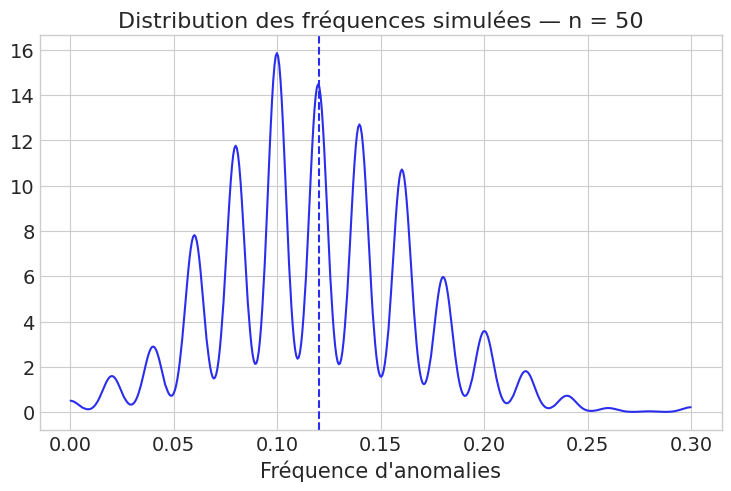

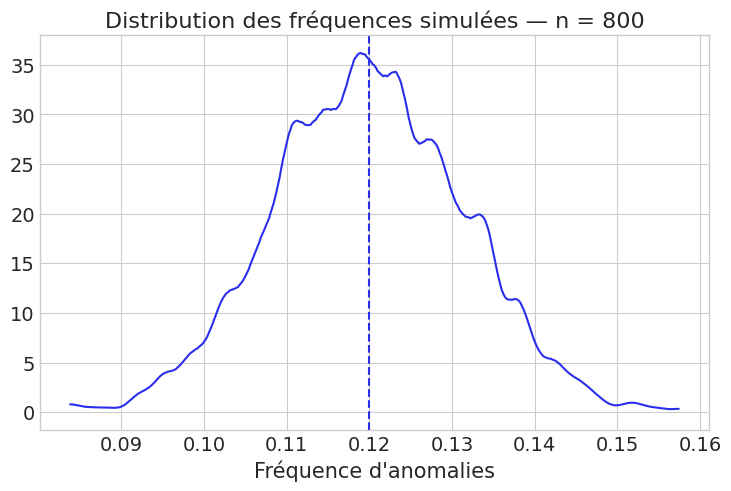

In [7]:
az.plot_dist(freqs_small)
plt.axvline(p_anomaly, linestyle="--")
plt.title("Distribution des fréquences simulées — n = 50")
plt.xlabel("Fréquence d'anomalies")
plt.show()

az.plot_dist(freqs_large)
plt.axvline(p_anomaly, linestyle="--")
plt.title("Distribution des fréquences simulées — n = 800")
plt.xlabel("Fréquence d'anomalies")
plt.show()

## Interprétation attendue

La fréquence empirique est une estimation de la probabilité réelle, mais elle dépend de l'échantillon observé.

Quand la taille de l'échantillon augmente, la moyenne des fréquences simulées reste proche de la probabilité réelle, mais la dispersion diminue. Cela montre que l'estimation devient plus stable.

Deux expériences avec les mêmes paramètres peuvent donner des résultats différents parce que chaque échantillon est soumis au hasard.

---
# Exercice 2 — Cybersecurity Alert System


## Données

On observe un système de cybersécurité sur 50 intrusions connues.

Le système a généré 30 alertes correctes.

On compare deux hypothèses :

- `H = 0` : système normal, probabilité de détection = 0.80
- `H = 1` : système dégradé, probabilité de détection = 0.50

In [8]:
np.random.seed(7)

n = 400
intrusion = np.random.binomial(1, 0.10, size=n)

detect_rate_normal = 0.80
detect_rate_compromised = 0.55

alerts = np.where(
    intrusion == 1,
    np.random.binomial(1, detect_rate_normal, size=n),
    np.random.binomial(1, 0.15, size=n)
)

## Modèle

Structure :

\[
H \rightarrow p_{detection} \rightarrow y
\]

Le résultat attendu est :

\[
P(H = 1 \mid données)
\]

In [9]:
with pm.Model() as cyber_model:

    H = pm.Bernoulli("H", p=0.2)

    detect_rate = pm.math.switch(
        H,
        detect_rate_compromised,
        detect_rate_normal
    )

    p_alert = pm.math.switch(
        intrusion,
        detect_rate,
        0.15
    )

    obs = pm.Bernoulli(
        "obs",
        p=p_alert,
        observed=alerts
    )

    idata_cyber = pm.sample(
        2000,
        tune=1000,
        return_inferencedata=True,
        random_seed=7
    )

Output()

In [10]:
H_samples = idata_cyber.posterior["H"].values.flatten()

p_H0 = (H_samples == 0).mean()
p_H1 = (H_samples == 1).mean()

print("P(H = 0 | données) =", p_H0)
print("P(H = 1 | données) =", p_H1)

P(H = 0 | données) = 0.99725
P(H = 1 | données) = 0.00275


## Interprétation attendue

`H` est une variable discrète, car les deux scénarios sont exclusifs. On utilise donc une loi `Categorical`.

On ne peut pas utiliser un `if` Python classique, car `H` est une variable aléatoire dans le modèle PyMC. On utilise donc `pm.math.switch`.

Avec 30 alertes correctes sur 50 intrusions, le taux observé est 0.60. Il est plus proche du scénario dégradé (0.50) que du scénario normal (0.80), mais il reste intermédiaire. Il faut donc interpréter le posterior plutôt que décider uniquement avec la fréquence brute.

---
# Exercice 3 — Online Learning Platform

## Données

Une plateforme éducative teste un nouvel algorithme de recommandation.

- 20 utilisateurs testent l'algorithme.
- 13 terminent le cours recommandé.

On note :

\[
p = P(terminer le cours)
\]

In [11]:
n_users = 20
success = 13

## Modèle avec prior neutre

In [12]:
with pm.Model() as learning_model:

    p = pm.Beta("p", alpha=2, beta=2)

    y = pm.Binomial(
        "y",
        n=n_users,
        p=p,
        observed=success
    )

    idata_learning = pm.sample(
        draws=2000,
        tune=1000,
        chains=2,
        random_seed=42
    )

Output()

In [13]:
az.summary(idata_learning, var_names=["p"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,0.625,0.097,0.449,0.808,0.002,0.001,1745.0,2388.0,1.0


<Axes: title={'center': 'p'}>

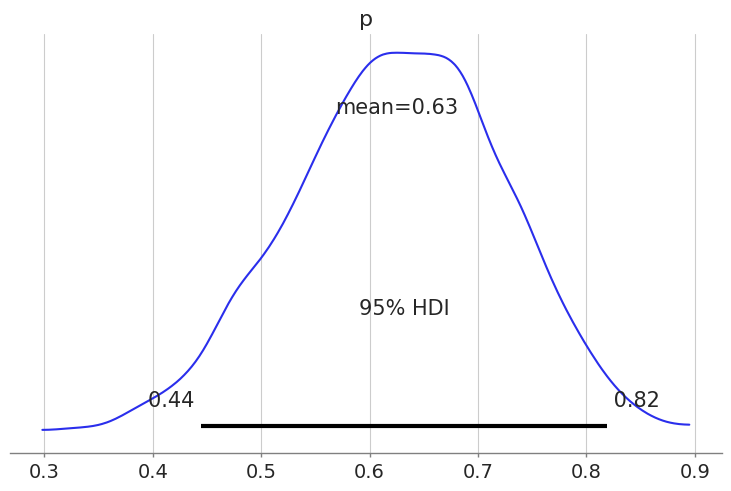

In [14]:
az.plot_posterior(idata_learning, var_names=["p"], hdi_prob=0.95)


## Probabilité de dépasser le seuil

In [15]:
samples_p = idata_learning.posterior["p"].values.flatten()

prob_above = (samples_p > 0.65).mean()

print("P(p > 0.65) =", prob_above)

P(p > 0.65) = 0.4165


## Décision

Règle :

- si `P(p > 0.65) >= 0.75` : déploiement ;
- si `0.50 <= P(p > 0.65) < 0.75` : test supplémentaire ;
- si `< 0.50` : abandon.

In [16]:
if prob_above >= 0.75:
    decision = "Déploiement"
elif prob_above >= 0.50:
    decision = "Test supplémentaire"
else:
    decision = "Abandon"

print("Décision :", decision)

Décision : Abandon


## Modèle avec prior optimiste Beta(6, 2)

In [17]:
with pm.Model() as learning_model_optimiste:

    p = pm.Beta("p", alpha=6, beta=2)

    y = pm.Binomial(
        "y",
        n=n_users,
        p=p,
        observed=success
    )

    idata_learning_optimiste = pm.sample(
        draws=2000,
        tune=1000,
        chains=2,
        random_seed=42
    )

Output()

In [18]:
az.summary(idata_learning_optimiste, var_names=["p"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,0.681,0.086,0.522,0.835,0.002,0.001,1738.0,2930.0,1.0


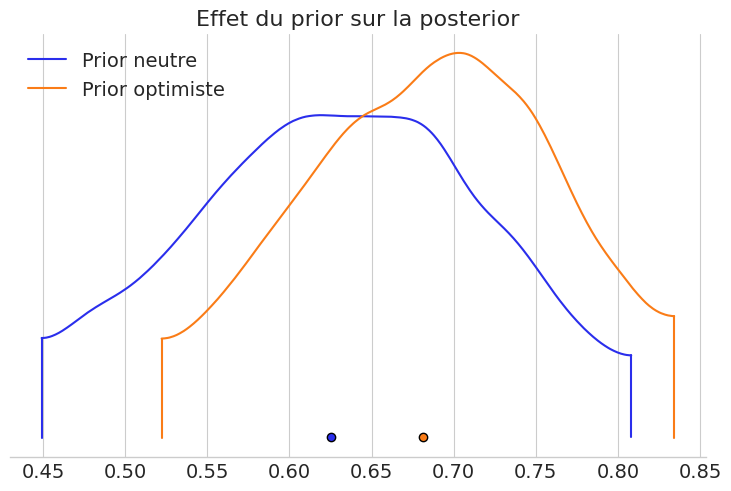

In [19]:
az.plot_density(
    [idata_learning, idata_learning_optimiste],
    var_names=["p"],
    data_labels=["Prior neutre", "Prior optimiste"]
)
plt.title("Effet du prior sur la posterior")
plt.show()

In [20]:
samples_p_optimiste = idata_learning_optimiste.posterior["p"].values.flatten()

prob_above_optimiste = (samples_p_optimiste > 0.65).mean()

print("P(p > 0.65) — prior neutre :", prob_above)
print("P(p > 0.65) — prior optimiste :", prob_above_optimiste)

P(p > 0.65) — prior neutre : 0.4165
P(p > 0.65) — prior optimiste : 0.6495


## Interprétation attendue

Le prior neutre laisse les données jouer le rôle principal. Le prior optimiste pousse la distribution vers des valeurs plus élevées de `p`.

Avec peu de données, le prior a un effet visible. C'est normal : 20 observations ne suffisent pas toujours à écraser complètement la croyance initiale.

La décision doit donc être justifiée par la probabilité calculée, pas seulement par le taux brut `13/20`.

---
# Exercice 4 — Voice Recognition System


## Données

In [21]:
data = np.array([5.1, 5.3, 5.0, 5.2, 9.8, 10.1, 9.9, 10.2])
group = np.array([0, 0, 0, 0, 1, 1, 1, 1])

print("Données :", data)
print("Moyenne empirique :", data.mean())
print("Écart-type empirique :", data.std(ddof=1))

Données : [ 5.1  5.3  5.   5.2  9.8 10.1  9.9 10.2]
Moyenne empirique : 7.574999999999999
Écart-type empirique : 2.596563663217765


## Modèle 1 — Une seule moyenne

In [22]:
with pm.Model() as model_simple:

    mu = pm.Normal("mu", mu=7.5, sigma=3)

    y = pm.Normal(
        "y",
        mu=mu,
        sigma=2,
        observed=data
    )

    idata_simple = pm.sample(
        draws=2000,
        tune=1000,
        chains=2,
        random_seed=42,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True}
    )

Output()

In [23]:
az.summary(idata_simple, var_names=["mu"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,7.555,0.689,6.244,8.864,0.017,0.01,1597.0,2674.0,1.0


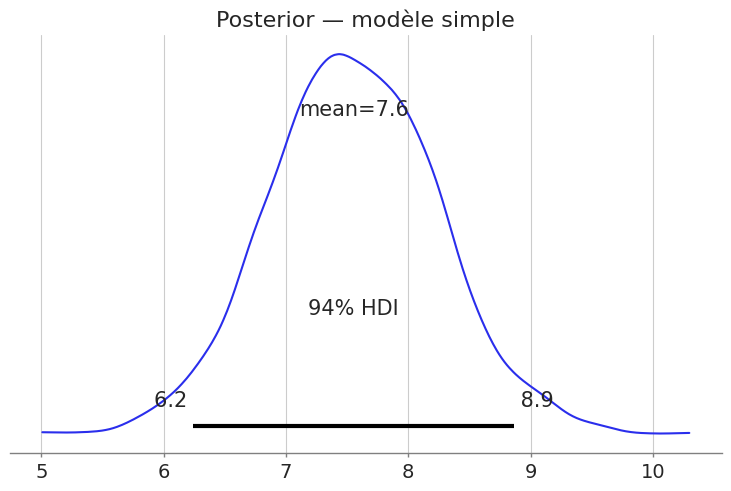

In [24]:
az.plot_posterior(idata_simple, var_names=["mu"])
plt.title("Posterior — modèle simple")
plt.show()

## Modèle 2 — Deux régimes

In [25]:
with pm.Model() as model_deux_regimes:

    mu = pm.Normal("mu", mu=[5, 10], sigma=1, shape=2)

    y = pm.Normal(
        "y",
        mu=mu[group],
        sigma=1,
        observed=data
    )

    idata_deux_regimes = pm.sample(
        draws=2000,
        tune=1000,
        chains=2,
        random_seed=42,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True}
    )

Output()

In [26]:
az.summary(idata_deux_regimes, var_names=["mu"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu[0],5.114,0.451,4.268,5.934,0.007,0.007,3858.0,2622.0,1.0
mu[1],9.999,0.446,9.143,10.814,0.007,0.007,4165.0,2980.0,1.0


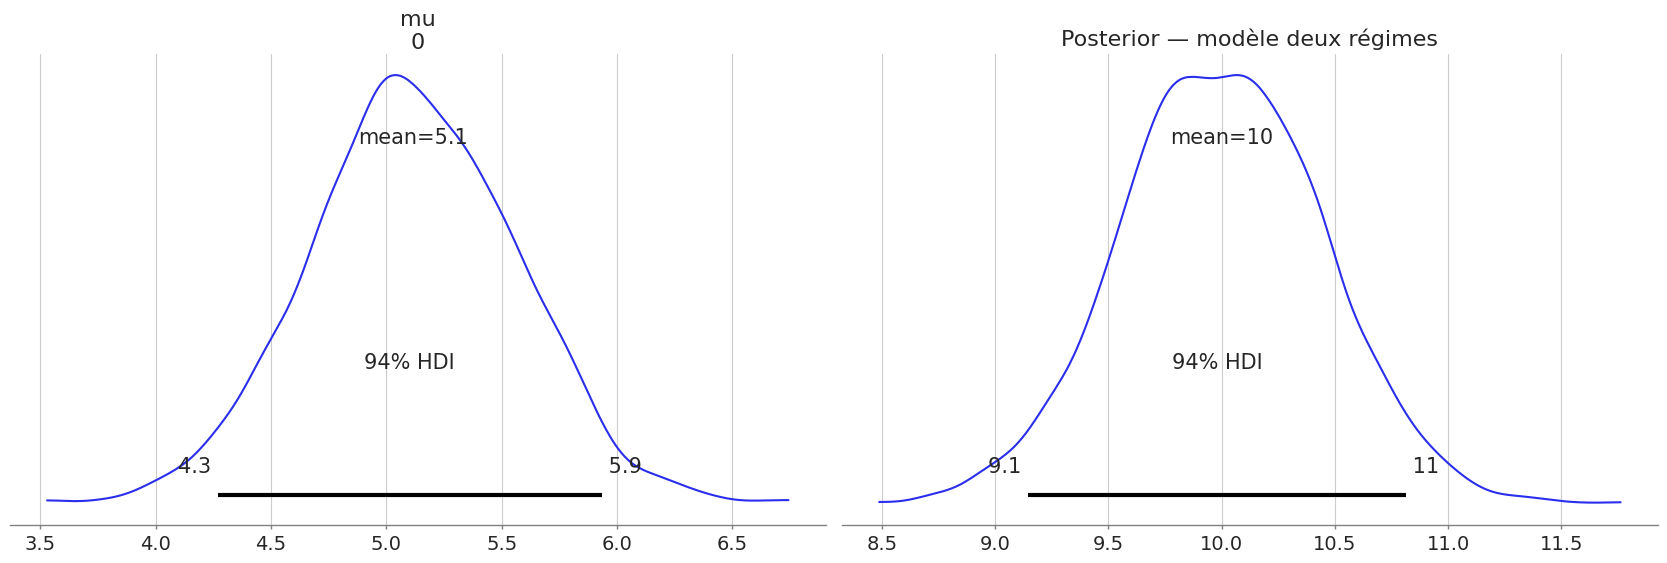

In [27]:
az.plot_posterior(idata_deux_regimes, var_names=["mu"])
plt.title("Posterior — modèle deux régimes")
plt.show()

## Comparaison des modèles

In [28]:
comparison = az.compare(
    {
        "modele_simple": idata_simple,
        "modele_deux_regimes": idata_deux_regimes
    }
)

comparison

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
modele_deux_regimes,0,-8.346458,0.198764,0.000000,1.000000e+00,0.025213,0.000000,False,log
modele_simple,1,-20.104619,1.484721,11.758161,7.105427e-14,0.269356,0.275143,False,log


## Posterior Predictive Check — modèle simple

Output()

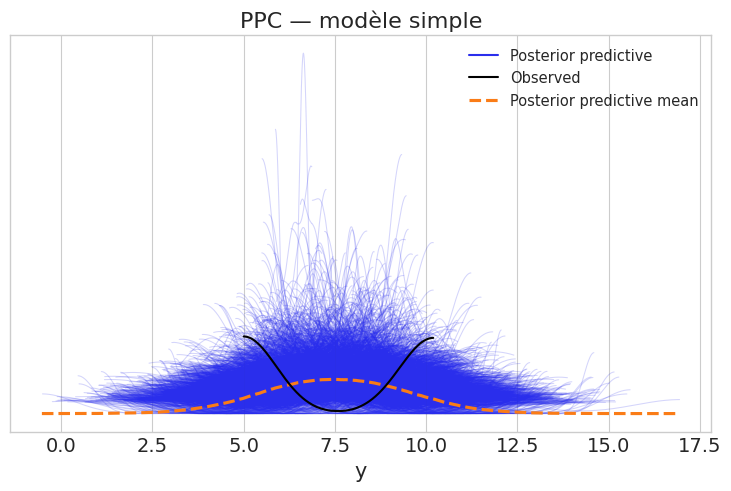

In [29]:
with model_simple:

    ppc_simple = pm.sample_posterior_predictive(
        idata_simple,
        return_inferencedata=False,
        random_seed=42
    )

idata_simple_ppc = az.from_dict(
    posterior={"mu": idata_simple.posterior["mu"].values},
    posterior_predictive={"y": ppc_simple["y"]},
    observed_data={"y": data}
)

az.plot_ppc(idata_simple_ppc)
plt.title("PPC — modèle simple")
plt.show()

## Posterior Predictive Check — modèle deux régimes

In [ ]:
with model_deux_regimes:

    ppc_deux_regimes = pm.sample_posterior_predictive(
        idata_deux_regimes,
        return_inferencedata=False,
        random_seed=42
    )

idata_deux_regimes_ppc = az.from_dict(
    posterior={"mu": idata_deux_regimes.posterior["mu"].values},
    posterior_predictive={"y": ppc_deux_regimes["y"]},
    observed_data={"y": data}
)

az.plot_ppc(idata_deux_regimes_ppc)
plt.title("PPC — modèle deux régimes")
plt.show()

Output()

## Interprétation attendue

Les données montrent deux groupes très nets : un autour de 5 et un autour de 10.

Le modèle simple estime une moyenne globale autour de 7.5, mais cette moyenne ne correspond pas vraiment à un régime observé. Elle est mathématiquement correcte, mais peu réaliste.

Le modèle à deux régimes est donc plus crédible. La comparaison ArviZ doit aller dans ce sens.

Le PPC permet de vérifier si le modèle reproduit correctement la forme générale des données. Un bon score de comparaison ne suffit pas : il faut encore vérifier la qualité générative du modèle.